# Práctica 2 — Ejercicio 3: Pingüinos Palmer

El dataset `penguins` contiene información sobre pingüinos de tres especies que anidan en el Archipiélago Palmer (Antártida): longitud y profundidad del pico (`bill_length_mm` y `bill_depth_mm`), longitud de la aleta (`flipper_length_mm`), masa corporal (`body_mass_g`) y sexo.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
%matplotlib inline

In [2]:
df = pd.read_csv("../Datasets/Parte_2/penguins.csv")
df = df.dropna(subset=["bill_length_mm", "flipper_length_mm", "species"])
print(f"Observaciones validas: {len(df)}")
print(df["species"].value_counts())
print(df[["bill_length_mm", "flipper_length_mm"]].describe())

Observaciones validas: 342
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64
       bill_length_mm  flipper_length_mm
count      342.000000         342.000000
mean        43.921930         200.915205
std          5.459584          14.061714
min         32.100000         172.000000
25%         39.225000         190.000000
50%         44.450000         197.000000
75%         48.500000         213.000000
max         59.600000         231.000000


## Ítem 1 — Visualización por especie

> **Realice un gráfico que le permita visualizar la relación que existe entre la longitud del pico y la longitud de la aleta de los pingüinos Palmer, según la especie. ¿Qué observa?**

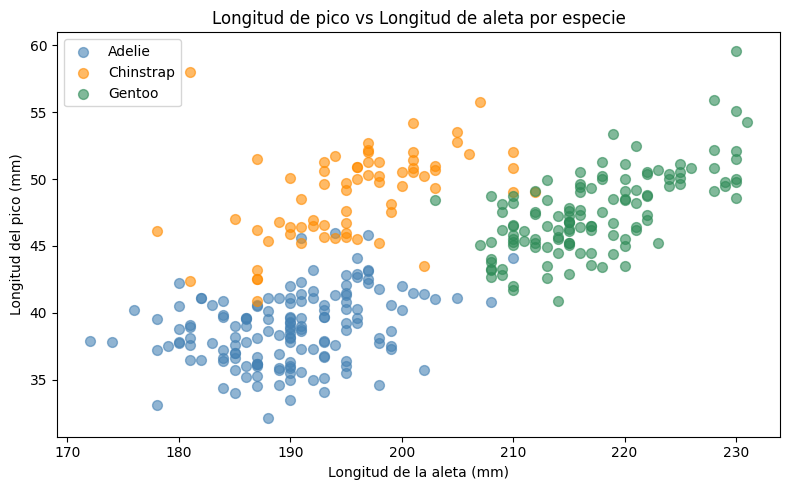

In [3]:
palette = {"Adelie": "steelblue", "Chinstrap": "darkorange", "Gentoo": "seagreen"}
fig, ax = plt.subplots(figsize=(8, 5))
for sp, grp in df.groupby("species"):
    ax.scatter(grp["flipper_length_mm"], grp["bill_length_mm"],
               label=sp, color=palette[sp], alpha=0.6, s=50)
ax.set_xlabel("Longitud de la aleta (mm)")
ax.set_ylabel("Longitud del pico (mm)")
ax.set_title("Longitud de pico vs Longitud de aleta por especie")
ax.legend()
plt.tight_layout()
plt.show()

**Observaciones:** Se observan tres nubes de puntos diferenciadas por especie.
- Los pinguinos **Gentoo** tienen aletas mas largas pero picos de longitud intermedia.
- Los pinguinos **Chinstrap** tienen picos mas largos en promedio.
- Los pinguinos **Adelie** tienen picos y aletas mas cortos.

La relacion entre longitud de aleta y pico **varia segun la especie** (lo que sugiere agregar
la especie como variable explicativa).

## Ítem 2 — Modelo 1: solo longitud de aleta

> **Ajuste un modelo de regresión lineal que le permita predecir la longitud promedio del pico de los pingüinos Palmer a partir de la longitud de la aleta (modelo 1).**

In [4]:
mod1 = smf.ols("bill_length_mm ~ flipper_length_mm", data=df)
res1 = mod1.fit()
print(res1.summary())
print(f"\nR2 ajustado: {res1.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     257.1
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           1.74e-43
Time:                        18:01:15   Log-Likelihood:                -968.98
No. Observations:                 342   AIC:                             1942.
Df Residuals:                     340   BIC:                             1950.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -7.2649      3.20

## Ítem 3 — Modelo 2: longitud de aleta + especie

> **A partir de las observaciones que realizó en el ítem 1, introduzca alguna modificación sobre el modelo inicial que le permita mejorar su capacidad predictiva para la longitud del pico de los pingüinos. Ajuste el nuevo modelo propuesto (modelo 2).**

In [5]:
mod2 = smf.ols("bill_length_mm ~ flipper_length_mm + C(species)", data=df)
res2 = mod2.fit()
print(res2.summary())
print(f"\nR2 ajustado: {res2.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     390.0
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          2.26e-109
Time:                        18:01:15   Log-Likelihood:                -809.56
No. Observations:                 342   AIC:                             1627.
Df Residuals:                     338   BIC:                             1642.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## Ítem 4 — Comparación de modelos

> **¿Cuál de los dos modelos (modelo 1, modelo 2) proporciona un mejor ajuste? ¿Qué métrica utilizó para compararlos?**

In [6]:
print(f"Modelo 1 -> R2 ajustado: {res1.rsquared_adj:.4f}")
print(f"Modelo 2 -> R2 ajustado: {res2.rsquared_adj:.4f}")
mejor = "Modelo 2" if res2.rsquared_adj > res1.rsquared_adj else "Modelo 1"
print(f"\nMejor modelo: {mejor} (mayor R2 ajustado)")

Modelo 1 -> R2 ajustado: 0.4289
Modelo 2 -> R2 ajustado: 0.7739

Mejor modelo: Modelo 2 (mayor R2 ajustado)


**Comparacion:** El Modelo 2 tiene un R² ajustado de 0.774, frente al 0.429 del Modelo 1.
Al incorporar la especie como variable categorica (con dummies), el modelo mejora
sustancialmente su capacidad explicativa. La especie es una variable con efecto
estadisticamente significativo.

## Ítem 5 — Predicción con el modelo seleccionado

> **Utilice el modelo seleccionado en el ítem anterior para predecir la longitud de pico que tendrá un pingüino Chinstrap de 17.6 mm de profundidad de pico, 191 mm de longitud de aleta, 3125 g de masa corporal y sexo masculino.**

In [7]:
# Pinguino Chinstrap: flipper=191mm, bill_depth=17.6mm, mass=3125g, sex=male
# El Modelo 2 usa flipper_length_mm y species
nuevo = pd.DataFrame({"flipper_length_mm": [191], "species": ["Chinstrap"]})
pred = res2.predict(nuevo)
print(f"Prediccion para pinguino Chinstrap (flipper=191mm):")
print(f"  Longitud de pico predicha = {pred.values[0]:.2f} mm")

Prediccion para pinguino Chinstrap (flipper=191mm):
  Longitud de pico predicha = 47.80 mm


## Conclusiones

- **Modelo 1:** La longitud de aleta por si sola explica el 43% de la variabilidad en la longitud del pico (R²adj = 0.429). Es un ajuste modesto.
- **Modelo 2:** Al agregar la especie como variable categorica, el R²adj sube a 0.774. Los coeficientes de especie son significativos (p < 0.001).
- **Metrica utilizada:** R² ajustado, que penaliza la inclusion de variables adicionales y es apropiado para comparar modelos con distinto numero de predictores.
- **Prediccion:** Para un pinguino Chinstrap con aleta de 191 mm, el Modelo 2 predice una longitud de pico de aproximadamente **47.80 mm**.